# Interventions

This is a notebook to intervene on proteins in different ways. Molecular biologists perform a range of interventions on the sequence level and try to determine the consequences, for example:
- alanine mutagenesis
- protein tagging
- phosphomimics

Here, we're tackling phosphomimic-type mutations.

### Questions:
- Can PLMs tell whether an intervention is biologically plausible, or do they just send any interventions into garbage latent space?

In [1]:
%load_ext autoreload
%autoreload 2

### Imports

In [2]:
import warnings
from polars.exceptions import MapWithoutReturnDtypeWarning

# This will ignore all UserWarning messages
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=MapWithoutReturnDtypeWarning)

In [22]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import re
from typing import List, Dict, Any
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import matthews_corrcoef


from project.utils.strs import SEED, plms, data_dir, interventions_results_dir, interventions_figures_dir, interventions_compiled_results_dir
from project.utils.functions import scramble_sequences, get_embeddings

from project.algorithms.networks.protein_language_model import ProteinLanguageModel

In [4]:
# Make dirs if they don't exist already
for directory in [interventions_results_dir, interventions_compiled_results_dir, interventions_figures_dir]:
    directory.mkdir(parents=True, exist_ok=True)

### Read in data


In [7]:
# Read annotated dataset
annotated_data = 'uniprotkb_AND_model_organism_9606_2025_09_09_annotated.parquet.gz'
df = pl.read_parquet(data_dir / annotated_data)
gene_name_mappings = dict(zip(df['sequence'].to_list(), df['id'].to_list()))

### Helper functions

In [8]:
# These functions are from 01a5_uniprot_annotations_datasets.ipynb

def annotate(features_str: str, feature_length: int, blank: str = '-', add_note=True) -> List[str]:
    """
    Parses a features string and updates a list with feature names or /note content,
    supporting both range (START..END) and point (POSITION) annotations.
    """
    # Initialize the feature list
    feature_list = [blank for _ in range(feature_length)]

    if features_str is None:
        return feature_list
    
    # Pattern:
    # 1. (\w+)\s+             - Group 1: Feature Code (e.g., 'LIPID')
    # 2. (\d+)                - Group 2: Start Position (or single position)
    # 3. (?:..(\d+))?         - Group 3 (Optional): Matches '..' followed by the End Position.
    #                          - If a range (..END) is not present, this group will be None.
    # 4. ;(?:.*?/note="([^"]+?)")? - Group 4 (Optional): Captures the /note content.
    feature_pattern = r'(\w+)\s+(\d+)(?:..(\d+))?;(?:.*?/note="([^"]+?)")?'
    
    # Find all matches (re.DOTALL allows '.' to match newlines if they existed)
    matches = re.finditer(feature_pattern, features_str, flags=re.DOTALL)
    
    for match in matches:
        # Groups: (Code, Start, End, Note)
        feature_name, start_str, end_str, note_content = match.groups()
        
        # Determine the value to place in the list
        if add_note and (note_content is not None) and not ('(' in note_content) and not (')' in note_content) and not (';' in note_content):
            fill_value = note_content
        else:
            fill_value = feature_name
            
        # Handle coordinates
        start = int(start_str)
        # If the '..END' part was matched, end_str will contain the number.
        # If it was a point annotation (e.g., 'LIPID 667;'), end_str will be None.
        end = int(end_str) if end_str else start 
        
        # Fill the list positions (adjusting for 0-based indexing)
        # The range is from start - 1 up to (but not including) end. 
        # For a point (start=end), this covers exactly one position.
        for i in range(start - 1, end):
            if i < len(feature_list):
                feature_list[i] = fill_value.replace(' ', '_')
                
    return feature_list


def combine_many_feature_lists(feature_lists: List[List[str]], blank: str = '-') -> List[str]:
    """
    Combines an arbitrary number of feature lists element-wise.
    """
    if not feature_lists:
        return []

    # All lists are assumed to be the same length (Polars enforces this structure)
    
    # Use zip to iterate through all lists simultaneously, getting a tuple of values per position
    # E.g., for position 'i', vals_at_pos = (list1[i], list2[i], list3[i], ...)
    combined_list = []
    
    # Transpose the lists using zip and convert to a list of tuples
    transposed_lists = list(zip(*feature_lists))
    
    for vals_at_pos in transposed_lists:
        # Find all values at the current position that are NOT the blank character
        labels = [val for val in vals_at_pos if val != blank]
        
        if not labels:
            # Case 1: All values are blank
            combined_list.append(blank)
        else:
            # Case 2/3: One or more labels are present
            # Use a set to get unique labels, then join them
            unique_labels = sorted(list(set(labels)))
            # if len(unique_labels) > 1:
            #     print(f"label overlap! {unique_labels}")
            combined_list.append(",".join(unique_labels))
            
    return combined_list

In [9]:
def find_regions(data_list, targets, pointwise=False):
    """
    Finds the start and end indices of contiguous regions where the elements
    contain ANY of the values in the 'targets' list as a substring.

    Args:
        data_list (list): The list of data (e.g., strings).
        targets (list): A list of substrings to find contiguous regions for.
        pointwise (bool): If True, returns all individual positions matching a target.

    Returns:
        list: A list of (start_index, end_index) tuples.
    """

    # Pre-process targets to lowercase once for efficiency
    targets_lower = [t.lower() for t in targets]

    def is_target_match(element, targets_list_lower):
        """Checks if the element contains any string in targets_list_lower as a substring."""
        if not isinstance(element, str):
            return False
        
        # Convert the element to lowercase before checking for substring presence
        element_lower = element.lower()
        
        # Check if the lowercase element contains ANY of the lowercase target strings
        return any(target in element_lower for target in targets_list_lower)

    if pointwise:
        return [i for i in range(len(data_list)) if is_target_match(data_list[i], targets_lower)]

    regions = []
    current_start = None
    n = len(data_list)

    for i in range(n):
        
        # Check if the current element is a substring match
        is_target = is_target_match(data_list[i], targets_lower)
        
        # Check if the previous element was a substring match
        is_prev_target = is_target_match(data_list[i-1], targets_lower) if i > 0 else False
        
        # Check for the start of a region
        if is_target and (i == 0 or not is_prev_target):
            current_start = i

        # Check for the end of a region
        if not is_target and is_prev_target:
            regions.append((current_start, i - 1))
            current_start = None

    # Handle the case where the region extends to the end of the list
    if current_start is not None and is_target_match(data_list[n-1], targets_lower):
        regions.append((current_start, n - 1))

    return regions

# Interventions

Note that there are more interventions than just phosphomimic - given more time, we would investigate the effects of these other interventions too!

In [10]:
def scramble_region(sequence, region_inds, seed):
    # Get the subsequence
    region = sequence[region_inds[0]:region_inds[1]]
    # Scramble it
    scrambled_region = scramble_sequences([region], seed=seed)[0] # since we only have one sequence, do list jiggery-pokery
    # Put it back into the protein
    full_seq = sequence[:region_inds[0]] + scrambled_region + sequence[region_inds[1]:]

    return full_seq

def excise_region(sequence:str, region_inds):
    """ 
    Given a sequence, remove a region marked by region_inds
    """
    return sequence[:region_inds[0]] + sequence[region_inds[1]:]

def insert_region(sequence: str, seq_to_insert: str, insertion_point: int) -> str:
    """
    Insert a sequence at a specific point in the main sequence.

    Args:
        sequence (str): The original protein sequence.
        seq_to_insert (str): The sequence to be inserted (e.g., a tag, a linker, or a foreign domain).
        insertion_point (int): The 0-based index *before* which the new sequence should be inserted.

    Returns:
        str: The resulting protein sequence.
    """
    return sequence[:insertion_point] + seq_to_insert + sequence[insertion_point:]

def replace_region(sequence: str, seq_to_insert: str, region_inds: tuple[int, int]) -> str:
    """
    Replaces a specified region in the original sequence with a new sequence.

    This function first removes the segment between region_inds[0] (inclusive)
    and region_inds[1] (exclusive), and then inserts 'seq_to_insert' at the
    point where the excision began (region_inds[0]).

    Args:
        sequence (str): The original protein sequence.
        seq_to_insert (str): The new sequence to be inserted (can be empty to just excise).
        region_inds (tuple[int, int]): A tuple (start_index, end_index) defining 
                                       the 0-based, half-open interval [start, end) to be replaced.

    Returns:
        str: The resulting protein sequence after replacement.
    """
    start_index = region_inds[0]
    end_index = region_inds[1]

    sequence_after_excision = sequence[:start_index] + sequence[end_index:]

    return sequence_after_excision[:start_index] + seq_to_insert + sequence_after_excision[start_index:]

def alanine_mutagenesis(sequence: str, positions: list[int]) -> str:
    """
    Mutates specified amino acid positions to Alanine (A). 
    Alanine scanning removes the side-chain functionality while preserving the backbone structure.

    Args:
        sequence (str): The original protein sequence.
        positions (list[int]): A list of 0-based indices of the residues to mutate.

    Returns:
        str: The Alanine-mutated sequence.
    """
    seq_list = list(sequence)
    for pos in positions:
        if 0 <= pos < len(seq_list):
            seq_list[pos] = 'A'
    return "".join(seq_list)

def glycine_mutagenesis(sequence: str, positions: list[int]) -> str:
    """
    Mutates specified amino acid positions to Glycine (G).
    Glycine scanning maximizes backbone flexibility at the position, often used to probe rigidity/flexibility requirements.

    Args:
        sequence (str): The original protein sequence.
        positions (list[int]): A list of 0-based indices of the residues to mutate.

    Returns:
        str: The Glycine-mutated sequence.
    """
    seq_list = list(sequence)
    for pos in positions:
        if 0 <= pos < len(seq_list):
            seq_list[pos] = 'G'
    return "".join(seq_list)

def phosphomimic(sequence: str, positions: list[int], mimic_type: str = 'activating') -> str:
    """
    Mutates phosphorylation sites (Serine/Threonine/Tyrosine) to mimic a permanently 
    phosphorylated or unphosphorylated state, choosing the best mimic for S/T/Y.

    Args:
        sequence (str): The original protein sequence.
        positions (list[int]): A list of 0-based indices of the residues to mutate.
        mimic_type (str): 'glutamic_acid' (E) or 'aspartic_acid' (D) for phospho-mimic, 
                          'non_phospho_A' (Alanine/default for S/T) or 'non_phospho_F' 
                          (Phenylalanine/default for Y) for non-phosphorylatable.
                          
    Returns:
        str: The resulting sequence with PTM site mutations.
    """
    
    ACTIVATING_MIMICS = {
        'S': 'E',
        'T': 'E',
        'Y': 'E'
    }
    INHIBITING_MIMICS = {
        'S': 'A',
        'T': 'A',
        'Y': 'F'
    }

    if mimic_type.lower() == 'activating':
        MIMIC_MAP = ACTIVATING_MIMICS
    elif mimic_type.lower() == 'inhibiting':
        MIMIC_MAP = INHIBITING_MIMICS
    else:
        raise ValueError("Invalid mimic_type. Choose 'activating' or 'inhibiting'.")

    seq_list = list(sequence)
    
    for pos in positions:
        
        # Check bounds and retrieve original residue
        if not (0 <= pos < len(seq_list)):
            continue 

        original_residue = seq_list[pos]
        
        # Apply the appropriate mutation if the residue is phosphorylatable
        if original_residue in MIMIC_MAP:
            # Look up the correct replacement residue from the chosen map
            seq_list[pos] = MIMIC_MAP[original_residue]
        else:
             # Use a warning print, but only print if not running in a bulk Polars/Pandas context
            #  print(f"Warning: Position {pos} ({original_residue}) is not a phosphorylation site (S, T, or Y). Skipping.")
             pass

    return "".join(seq_list)

TRAFFICKING_SIGNALS = {
    "nucleus": "PKKKRKV",       # Nuclear Localization Signal (NLS - SV40 T-antigen)
    "ER_retention": "KDEL",    # Endoplasmic Reticulum (ER) Retention Signal
    "peroxisome": "SKL",       # Peroxisome Targeting Signal 1 (PTS1)
    "mitochondria": "MLRTSSSLRSPFFSL", # Simplified Mitochondrial Transit Peptide (highly variable)
    "cytosol": ""              # Effectively removes any signal, defaulting to cytosol/default location
}

def relocalize(sequence: str, target_compartment: str, insertion_point: int = 0) -> str:
    """
    Add a trafficking signal to the protein to target it to the given compartment.

    Args:
        sequence (str): The full protein sequence.
        target_compartment (str): The desired cellular compartment (e.g., 'nucleus', 'ER_retention', 'mitochondria').
        insertion_point (int): Where to insert the signal (0 for N-terminus, len(sequence) for C-terminus, or an internal point).

    Returns:
        str: The sequence with the new trafficking signal.
    """
    signal = TRAFFICKING_SIGNALS.get(target_compartment.lower())
    if signal is None:
        raise ValueError(f"Unknown target compartment: {target_compartment}. Available: {list(TRAFFICKING_SIGNALS.keys())}")
    
    # Trafficking signals are typically added to the N-terminus or C-terminus.
    # The default for many NLS/MTPs is the N-terminus (index 0).
    return insert_region(sequence, signal, insertion_point)

# A dictionary of common epitope tags and their one-letter amino acid sequences
EPITOPE_TAGS = {
    "FLAG": "DYKDDDDK",     # Often N-terminal or internal
    "HA": "YPYDVPDYA",       # Hemagglutinin tag
    "MYC": "EQKLISEEDL",     # c-Myc tag
    "HIS6": "HHHHHH",        # 6x Histidine tag (for purification)
    "V5": 'GKPIPNPLLGLDST', # V5 Epitope Tag
    "SBP": "MDEKTTGWRGGHVVEGLAGELEQLPMGAIAEGMG", # Streptavidin Binding Peptide (for purification)
    "GST": """PMSILGYWETVRGWLGLGRPGLLKQLRKEFGEAQKRVDGWLDKQYITEYIKNTFSEQLDFIDKRTRIDMRNQLIDLMYNCELFEKLEP
    GENMRRYCSERFLDRYQLRDSRMSIYLTEEGEKRLHSSADGTLCYLREKLGYSNLRSTHSPGEFLLLFNAPYLQAKLSSEFGVRTTRHVPTRGDVD
    YTLFRSELFEQLCIDVERVEMAEKLGLDGSGKEFLLAPSLVLGSIPWSRVLDGLAQLLLKVFD""", # Soluble expression tag
    "EGFP": """MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTLTYGVQCFSRYPDHMKRHDFFKSAMPEGYV
    QERTIFFKDDGNYKTRAEVKFEGDTLVNRIVELKGIDFKEDGNILGHKLEYNFNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLL
    PDNHYLSYQSALSKDPNEKRDHMVLLEFVTAAGITLGMDELYK""",# Enhanced Green Fluorescent Protein
    "mCherry": """MVSKGEEDNMAIIKEFMRFKVHMEGSVNGHEFEIEGEGEGRPYEGTQTAFGSGVQCFSRYPDHMKRHDFFKSAMPEGYIQERTIFFKDDGNYK
    TRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNISHNVYITADKQKNGIKANFKIRHNVDGSVQLADHYQQNTPIGDGPVLLPDNHYLSYQSTFSKDPNE
    KRDHMVLLEFVTAAGITHGMDELYK""",
    "miniGFP": "MEKSFVITDPWLPDYPIISASDGFLELTEYSRDEIMGRNARFLQGPETDQATVQKIRDAIRDRRPTTVQLINYTKSGKKFWNLLHLQPVFDGKGGLQYFIGVQLVGSDHV",
}

def epitope_tagging(sequence: str, tag_name: str, location: str = 'C', linker: str = "") -> str:
    """
    Adds a specified epitope tag to the N- or C-terminus of a protein sequence.

    Args:
        sequence (str): The original protein sequence.
        tag_name (str): The name of the tag (e.g., 'FLAG', 'HA', 'HIS6').
        location (str, optional): 'N' for N-terminus (start) or 'C' for C-terminus (end). Defaults to 'C'.
        linker (str, optional): An optional, flexible amino acid linker sequence (e.g., 'GGGGSGGGGS') to insert between the protein and the tag. Defaults to "".

    Returns:
        str: The sequence with the epitope tag attached.
    """
    tag_name = tag_name.upper()
    location = location.upper()

    if tag_name not in EPITOPE_TAGS:
        raise ValueError(f"Unknown tag: {tag_name}. Available tags: {list(EPITOPE_TAGS.keys())}")
        
    tag_seq = EPITOPE_TAGS[tag_name]

    if location == 'N':
        # N-terminus: Tag + Linker + Sequence
        return tag_seq + linker + sequence
    elif location == 'C':
        # C-terminus: Sequence + Linker + Tag
        return sequence + linker + tag_seq
    else:
        raise ValueError("Invalid location. Must be 'N' (N-terminus) or 'C' (C-terminus).")

def swap_domains_internal(sequence: str, domain1_inds: tuple[int, int], domain2_inds: tuple[int, int]) -> str:
    """
    Swaps the position of two non-overlapping domains within a single protein sequence.

    Args:
        sequence (str): The full protein sequence.
        domain1_inds (tuple[int, int]): The (start, end) indices of the first domain (Python slice-style: [start:end]).
        domain2_inds (tuple[int, int]): The (start, end) indices of the second domain (Python slice-style: [start:end]).

    Returns:
        str: The protein sequence with the two domains swapped.
    """
    # 1. Extract Sequences
    d1_start, d1_end = domain1_inds
    d2_start, d2_end = domain2_inds
    
    domain1_seq = sequence[d1_start:d1_end]
    domain2_seq = sequence[d2_start:d2_end]
    
    # 2. Identify the Three Regions of the Sequence that are NOT part of the domains
    
    # A. N-terminal Region (before the first domain)
    # Determine which domain is first in the sequence
    if d1_start < d2_start:
        first_domain = domain1_seq
        first_start = d1_start
        first_end = d1_end
        second_domain = domain2_seq
        second_start = d2_start
        second_end = d2_end
    else:
        first_domain = domain2_seq
        first_start = d2_start
        first_end = d2_end
        second_domain = domain1_seq
        second_start = d1_start
        second_end = d1_end
        
    n_terminal_seq = sequence[:first_start]
    
    # B. Linker Region (between the two domains)
    linker_seq = sequence[first_end:second_start]
    
    # C. C-terminal Region (after the second domain)
    c_terminal_seq = sequence[second_end:]
    
    # 3. Assemble the Swapped Sequence
    # The swapped order is: N-term + Second_Domain + Linker + First_Domain + C-term
    swapped_seq = n_terminal_seq + second_domain + linker_seq + first_domain + c_terminal_seq
    
    return swapped_seq

def helix_breaking_mutagenesis(sequence: str, helix_start: int, helix_end: int, break_positions: list[int]) -> str:
    """
    Mutates specific residues within a predicted alpha-helix to Proline (P) to disrupt the helix structure.

    Args:
        sequence (str): The original protein sequence.
        helix_start (int): The 0-based index of the start of the predicted alpha-helix (inclusive).
        helix_end (int): The 0-based index of the end of the predicted alpha-helix (exclusive).
        break_positions (list[int]): A list of 0-based indices within the helix to mutate to Proline (P).

    Returns:
        str: The sequence with the helix-breaking Proline mutations.
    """
    seq_list = list(sequence)
    mutated_count = 0

    for pos in break_positions:
        if pos < helix_start or pos >= helix_end:
            print(f"Warning: Position {pos} is outside the defined helix region [{helix_start}, {helix_end}). Skipping.")
            continue
        
        if 0 <= pos < len(seq_list):
            original_residue = seq_list[pos]
            seq_list[pos] = 'P'
            mutated_count += 1
            print(f"Mutated residue at index {pos}: {original_residue} -> P")
        
    if mutated_count == 0:
         print("No mutations were applied.")
         
    return "".join(seq_list)

def create_chimeric_fusion(sequence_a: str, domain_b_seq: str, fusion_type: str = 'C-terminus', linker: str = "GGGS") -> str:
    """
    Fuses the primary protein (A) with a regulatory or catalytic domain (B) to create a chimera.

    Args:
        sequence_a (str): The sequence of the primary protein (A).
        domain_b_seq (str): The sequence of the domain to be fused (B) (e.g., a kinase domain, a transcriptional activator, or a light-sensitive domain).
        fusion_type (str, optional): 'C-terminus' (A-B) or 'N-terminus' (B-A). Defaults to 'C-terminus'.
        linker (str, optional): A flexible linker sequence to separate the two domains. Defaults to 'GGGS'.

    Returns:
        str: The sequence of the chimeric fusion protein.
    """
    fusion_type = fusion_type.upper()
    
    if fusion_type == 'C-TERMINUS':
        # Protein A - Linker - Domain B
        fused_seq = sequence_a + linker + domain_b_seq
        print(f"Created C-terminal fusion: A({len(sequence_a)}aa) + Linker + B({len(domain_b_seq)}aa)")
    elif fusion_type == 'N-TERMINUS':
        # Domain B - Linker - Protein A
        fused_seq = domain_b_seq + linker + sequence_a
        print(f"Created N-terminal fusion: B({len(domain_b_seq)}aa) + Linker + A({len(sequence_a)}aa)")
    else:
        raise ValueError("Invalid fusion_type. Choose 'C-terminus' or 'N-terminus'.")
        
    return fused_seq

# PTM experiments

### Assemble a toy / small dataset

Pick proteins that have the desired characteristic. We'll start with phosphorylation because it's both common and useful to know how much PLMs recognize it.

Q13492 = PICALM

Selecting proteins with annotated phosphorylation:

In [11]:
# Parse PTMs
target_col = 'Modified residue'
placeholder = '-'
residues_col = f"{target_col.replace(' ', '_').lower()}_per_residue"
phospho_df = df.filter(~pl.col(target_col).is_null()).with_columns(
            pl.struct([
                pl.col(target_col), 
                pl.col('Length')
            ]) # Use pl.struct to bundle the feature string and the length.
            .map_elements(lambda x: annotate(
                features_str=x[target_col], 
                feature_length=x['Length'],
                blank = placeholder,
                add_note=True,
            ), return_dtype=pl.List(pl.String))
            .alias(residues_col)
        ).select(['id', 'sequence', 'Entry Name', target_col, residues_col])

ps_filter = (pl.element().str.to_lowercase().str.contains("phosphoserine"))
pt_filter = (pl.element().str.to_lowercase().str.contains("phosphothreonine"))
py_filter = (pl.element().str.to_lowercase().str.contains("phosphotyrosine"))
# Add a flag for whether there's a phosphoserine or threonine and filter down to just those proteins
phospho_df = phospho_df.with_columns(
    pl.col(residues_col).list.eval(
        # Check if the inner element contains 'phosphothreonine' OR 'phosphoserine' (case-insensitive)
        ps_filter | pt_filter | py_filter 
      )
      # Check if ANY of the boolean results in the list is True
      .list.any()
      .alias("contains_psite")
    ).filter(pl.col('contains_psite'))

Helper function to generate phosphorylation mutants

In [12]:

def generate_mutants(
    row: Dict[str, Any],
    mutation_column: str = 'all_possible',
    annotation_column:str = 'phospho',
    pointwise=True,
) -> List[Dict[str, Any]]:
    """Generates a list of new rows (mutants) for a single original row."""
    
    # Access values directly from the dictionary/struct
    original_seq = row['sequence']
    mutation_positions = row[mutation_column]
    expected_positive_positions = row[annotation_column]
    row_id = row['id']
    entry_name = row['Entry Name']
    
    # Ensure positions is a list of integers
    if not isinstance(mutation_positions, list) or not mutation_positions:
        mutation_positions = []
    if not isinstance(expected_positive_positions, list) or not expected_positive_positions:
        expected_positive_positions = []
    
    # Base case: Original sequence
    results = [{
        'id': row_id, 
        'Entry Name': entry_name,
        'sequence': original_seq, 
        'mutation_type': 'original', 
        'mutation': None,
        'expected_result': 'active',
    }]

    ACTIVATING_MIMICS = {
        'S': 'E',
        'T': 'E',
        'Y': 'E'
    }
    INHIBITING_MIMICS = {
        'S': 'A',
        'T': 'A',
        'Y': 'F'
    }

    if pointwise:
        for position in mutation_positions:
            aa_at_position = original_seq[position]

            # Define all mutations to apply
            mutations = [
                # Alanine Scanning
                ('alanine_mutagenesis', 'A', alanine_mutagenesis(original_seq, [position])),
                # Glycine Scanning
                ('glycine_mutagenesis', 'G', glycine_mutagenesis(original_seq, [position])),
                # Phosphomimic
                ('phosphomimic_activating', ACTIVATING_MIMICS[aa_at_position], phosphomimic(original_seq, [position], 'activating')),
                ('phosphomimic_inhibiting', INHIBITING_MIMICS[aa_at_position], phosphomimic(original_seq, [position], 'inhibiting')),
            ]

            # Append the new mutant rows
            for type_name, res_aa, new_seq in mutations:
                expected_result = 'unknown' # default is that we don't know the effect
                position_check = (position in expected_positive_positions) # If the mutation is at a position we expect to have an effect on phenotype of interest (phosphorylation)
                activation_check = ('activating' in type_name.lower()) # If the mutation is activating or inhibiting
                # If we're making a mutation at a position thought to have the modification, it's either activatory or inhibitory
                if position_check:
                    if activation_check:
                        expected_result = 'active'
                    else:
                        expected_result = 'inactive'

                # Only add if the mutation actually resulted in a change
                if new_seq != original_seq:
                    results.append({
                        'id': row_id, 
                        'sequence': new_seq, # The new, mutated sequence
                        'Entry Name': entry_name,
                        'mutation_type': type_name, 
                        'mutation': f"{aa_at_position}{position+1}{res_aa}",
                        'expected_result': expected_result,
                    })
    else:
        # We want to implement combinations of mutations!
        
        print('expecting to assign pointwise mutations! Multiple mutations not yet implemented')
            
    return results

# Define the expected output data type
OUTPUT_DTYPE = pl.List(pl.Struct([
    pl.Field("id", pl.Utf8),
    pl.Field("sequence", pl.Utf8),
    pl.Field("Entry Name", pl.Utf8),
    pl.Field("mutation_type", pl.Utf8),
    pl.Field("mutation_residues", pl.Utf8),
    pl.Field("expected_result", pl.String)
]))

# Performing in-silico mutagenesis and getting embeddings

It doesn't make sense to subtract the mutant embeddings from the control embedding, because the wild-type protein should have a baseline level of activity and we're asking whether the protein is predicted active or inactive, rather than if it'll be inactive, active, or hyper-active. We will:
- Randomly sample a protein
- Perform all possible phospho-mutations
- Train a logistic regression classifier to predict from embeddings whether the given protein is active, inactive, or unknown (using train:test split to try to make sure it's not just memorizing)
- Perform label corruption to check that the LR classifier is actually associating embeddings with labels

In [5]:
n_times = 500
test_size = 0.3
outgroup_size = 25
lr_iters = 350 # 250-500 is usually a good place to start
model_shorthand = 'amplify_350m'
model_name = plms[model_shorthand]['full_name']

In [ ]:
if not (interventions_results_dir / f"phosphomimic_preds_{model_shorthand}_{n_times}_samples_seed_{SEED}.parquet.gz").exists():

    result_dfs = []
    all_mutant_embeddings = []

    for time in range(n_times):
        # Instantiate PLM to run sequences through
        protein_language_model = ProteinLanguageModel(model_name = model_name, layer_to_use= None)

        # Randomly sample a protein (different seed than the random samples above)
        subset_df = phospho_df.sample(1, seed=SEED+time+1)

        # Find which residues are serine, threonine, or tyrosine, and which have phospho annotations 
        # Need to do this before because the mutation needs the 'all_{}' column
        subset_df = subset_df.with_columns(
            pl.col('sequence').map_elements(lambda x: find_regions(x, ['S','Y','T'], pointwise=True),).alias('all_possible'), # Get all possible phosphorylation sites
            pl.col(residues_col).map_elements(lambda x: find_regions(x, ['phosphoserine', 'phosphotyrosine', 'phosphothreonine'], pointwise=True)).alias('phospho'), # Get all annotated
        ).with_columns(
            pl.col('phospho').list.len().alias('num_predicted_sites')
        )

        # Mutate all
        mutant_df = subset_df.select(
            pl.struct(['id', 'sequence', 'Entry Name', 'all_possible', 'phospho'])
            .map_batches(
                # The inner apply ensures the Struct elements are passed as Python dicts
                lambda s: s.map_elements(
                    lambda row_dict: generate_mutants(row_dict, mutation_column='all_possible', annotation_column='phospho'),
                    # Inner return dtype is the Struct
                    return_dtype=OUTPUT_DTYPE.inner
                ),
                # Outer return dtype is the List[Struct]
                return_dtype=OUTPUT_DTYPE,
            )
            .alias("mutant_rows")
        )
        final_mutant_df = mutant_df.explode("mutant_rows").unnest("mutant_rows")
        num_activ = len(final_mutant_df.filter(pl.col('expected_result') == 'Activation'))
        # Keep track of how many sites the protein has
        final_mutant_df = final_mutant_df.with_columns(
            pl.lit(num_activ).alias('num_sites')
        )

        mutant_sequences = final_mutant_df['sequence'].to_list()

        # Get embeddings for each mutant we've generated (this includes the original protein!)
        mutant_embeddings = get_embeddings(mutant_sequences, protein_language_model, batch_size = 8, layer_nums = range(plms[model_shorthand]['num_hiddens']), pooled=True)

        # Convert embeddings to numpy to do some things
        mutant_embeddings_np = {k:v.numpy() for k,v in mutant_embeddings.items()}
        
        layer_dfs = []

        for layer_num, embeddings_at_layer in mutant_embeddings_np.items():

            X = embeddings_at_layer
            # Turn labels into multiclass labels
            le = LabelEncoder()
            y_true = le.fit_transform(final_mutant_df['expected_result']) # Transform string labels into numeric so ML works

            # Train test split the embeddings and labels so we're not just memorizing
            X_train, X_test, y_train, y_test = train_test_split(X, y_true, test_size=test_size, random_state=SEED, stratify=y_true)

            # Try a logistic regression to predict the expected result (heavily unbalanced data! use class_weight balanced to try to hedge against this)
            lr = LogisticRegression(random_state=SEED, class_weight='balanced', max_iter=lr_iters)
            lr.fit(X_train, y_train)
            lr_predictions = lr.predict(X) # Store all predictions
            lr_score = matthews_corrcoef(lr.predict(X_test), y_test) # Just score the test set predictions
            lr_predictions_labels = le.inverse_transform(lr_predictions).tolist()

            # Do a logistic regression on the same data but imagine if other sites had been expected active
            # Counterfactual label corruption - shuffle the labels. We shouldn't see the same as for the true expected active
            lr_counter = LogisticRegression(random_state=SEED, class_weight='balanced', max_iter=lr_iters)
            # Corrupt the full label set y_true
            y_corrupted = y_true.copy()
            np.random.RandomState(SEED).shuffle(y_corrupted)
            # split the corrupted labels the exact same way as the true split
            X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_corrupted, test_size=test_size, random_state=SEED, stratify=y_true)
            # Fit the model on corrupted labels
            lr_counter.fit(X_train_c, y_train_c)
            lr_counter_predictions = lr_counter.predict(X)
            lr_counter_score = matthews_corrcoef(lr_counter.predict(X_test_c), y_test_c)
            lr_counter_predictions_labels = le.inverse_transform(lr_counter_predictions).tolist()
            
            # Store results
            layer_df = final_mutant_df.with_columns(
                pl.lit(layer_num).alias('layer_num'),
                pl.lit(time).alias('run_id'),
                # pl.lit(probe_predictions.sum().item() == 0).alias('probe_recognition_of_original'),
                pl.lit(lr_score).alias('lr_score'),
                pl.lit(lr_predictions).alias('lr_predictions'),
                pl.Series(name = 'lr_predictions_labels', values=lr_predictions_labels, dtype=pl.String),
                pl.lit(lr_counter_score).alias('lr_score_on_corrupted'),
                pl.lit(lr_counter_predictions).alias('lr_corrupted_predictions'),
                pl.Series(name = 'lr_corrupted_predictions_labels', values=lr_counter_predictions_labels, dtype=pl.String),
            )

            layer_dfs.append(layer_df)
        
        
        result_dfs.append(pl.concat(layer_dfs))

    # combine results
    results = pl.concat(result_dfs).sort(by=['layer_num', 'num_sites'])

    # export results
    results.write_parquet(interventions_results_dir / f"phosphomimic_preds_{model_shorthand}_{n_times}_samples_seed_{SEED}.parquet.gz")
    # took 314m16s to do 500

In [15]:
results

id,Entry Name,sequence,mutation_type,mutation,expected_result,num_sites,layer_num,run_id,lr_score,lr_predictions,lr_predictions_labels,lr_score_on_corrupted,lr_corrupted_predictions,lr_corrupted_predictions_labels
str,str,str,str,str,str,i32,i32,i32,f64,i64,str,f64,i64,str
"""Q5SNT2""","""TM201_HUMAN""","""MEGVSALLARCPTAGLAGGLGVTACAAAGV…","""phosphomimic_inhibiting""","""S237A""","""unknown""",0,0,450,0.297412,2,"""unknown""",0.035294,1,"""inactive"""
"""Q5SNT2""","""TM201_HUMAN""","""MEGVSALLARCPTAGLAGGLGVTACAAAGV…","""glycine_mutagenesis""","""S237G""","""unknown""",0,0,450,0.297412,2,"""unknown""",0.035294,2,"""unknown"""
"""Q8N7B9""","""EFCB3_HUMAN""","""MAVGEIKPKLKLNPLTKVPISHNKRDRDLP…","""glycine_mutagenesis""","""S4G""","""unknown""",0,0,0,0.140936,2,"""unknown""",-0.055153,2,"""unknown"""
"""Q8N7B9""","""EFCB3_HUMAN""","""MAVEEIKPKLKLNPLTKVPISHNKRDRDLP…","""phosphomimic_activating""","""S4E""","""unknown""",0,0,0,0.140936,2,"""unknown""",-0.055153,2,"""unknown"""
"""Q8N7B9""","""EFCB3_HUMAN""","""MAVAEIKPKLKLNPLTKVPISHNKRDRDLP…","""phosphomimic_inhibiting""","""S4A""","""unknown""",0,0,0,0.140936,2,"""unknown""",-0.055153,2,"""unknown"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Q7Z4W1""","""DCXR_HUMAN""","""MELFLAGRRVLVTGAGKGIGRGTVQALHAT…","""phosphomimic_inhibiting""","""S233A""","""unknown""",0,31,499,0.702439,2,"""unknown""",-0.018858,2,"""unknown"""
"""Q7Z4W1""","""DCXR_HUMAN""","""MELFLAGRRVLVTGAGKGIGRGTVQALHAT…","""alanine_mutagenesis""","""T234A""","""unknown""",0,31,499,0.702439,2,"""unknown""",-0.018858,2,"""unknown"""
"""Q7Z4W1""","""DCXR_HUMAN""","""MELFLAGRRVLVTGAGKGIGRGTVQALHAT…","""glycine_mutagenesis""","""T234G""","""unknown""",0,31,499,0.702439,2,"""unknown""",-0.018858,2,"""unknown"""


In [6]:
results = pl.read_parquet(interventions_results_dir / f"phosphomimic_preds_{model_shorthand}_{n_times}_samples_seed_{SEED}.parquet.gz")

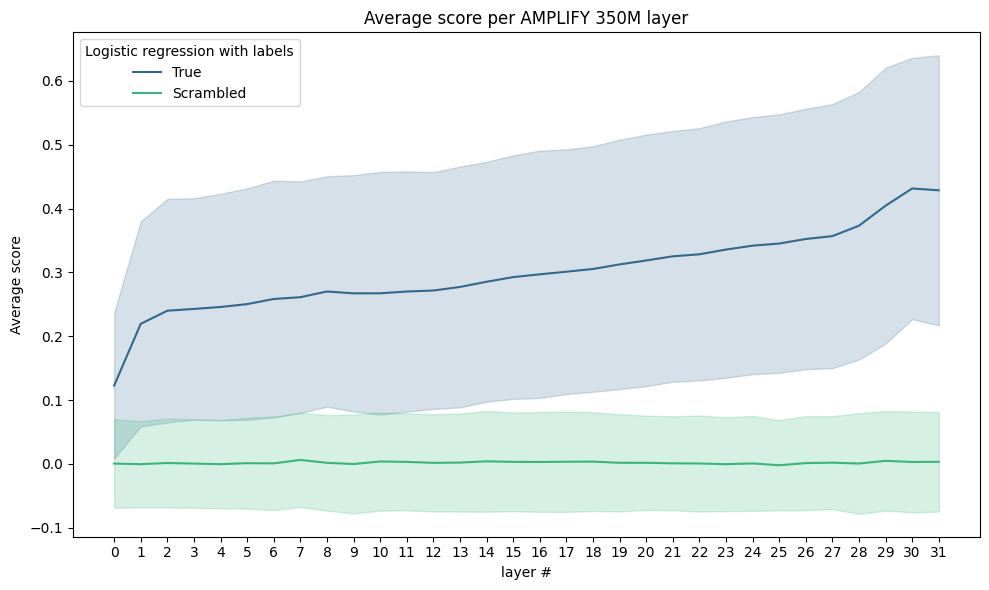

In [7]:
# --- 2. Melt the DataFrame (Wide to Long Format) ---

df_long = results.to_pandas().melt(
    id_vars=['layer_num'],
    value_vars=['lr_score', 'lr_score_on_corrupted'],
    var_name='label',
    value_name='score'
)

# Rename labels for clarity in the legend
df_long['label'] = df_long['label'].replace({
    'lr_score': 'True', 
    'lr_score_on_corrupted': 'Scrambled'
})


# --- 3. Plot the Results using Seaborn ---
# Define plot columns based on the melted DataFrame
score_col = 'score'
x_col = 'layer_num'
hue_col = 'label'

plt.figure(figsize=(10, 6))

# Seaborn lineplot handles the mean and CI calculation correctly
# because 'df_long' now has multiple independent 'score' observations 
# for each 'layer_num' and 'label' (assuming your original 'results' had them).
sns.lineplot(
    data=df_long,
    x=x_col,
    y=score_col,
    hue=hue_col,
    # marker='o',
    errorbar='sd',
    linestyle='-',
    palette='viridis',
)

# Set labels, title, and other plot properties
plt.title(f'Average {score_col} per {model_shorthand.replace('_', ' ').upper()} layer')
plt.xlabel(f'layer #')
plt.ylabel(f'Average {score_col}')
plt.legend(title='Logistic regression with labels')
plt.grid(axis='y', linestyle='')

plt.xticks(sorted(df_long[x_col].unique().astype(int))) 
plt.tight_layout()

# Save the plot
plt.savefig(interventions_figures_dir / f"phosphomimic_preds_{model_shorthand}_{n_times}_samples_seed_{SEED}.png")

### Statistical testing for differences

Is there a real relationship between the embeddings and the output (ie. if we scramble labels, do we lose the relationship)?
We want to test if there are differences between lr_score and lr_score_on_corrupted, per layer, and considering each protein. 

We'll use a Wilcoxon signed-rank test because we have pairs: proteins with either the correct or a corrupted label. The 

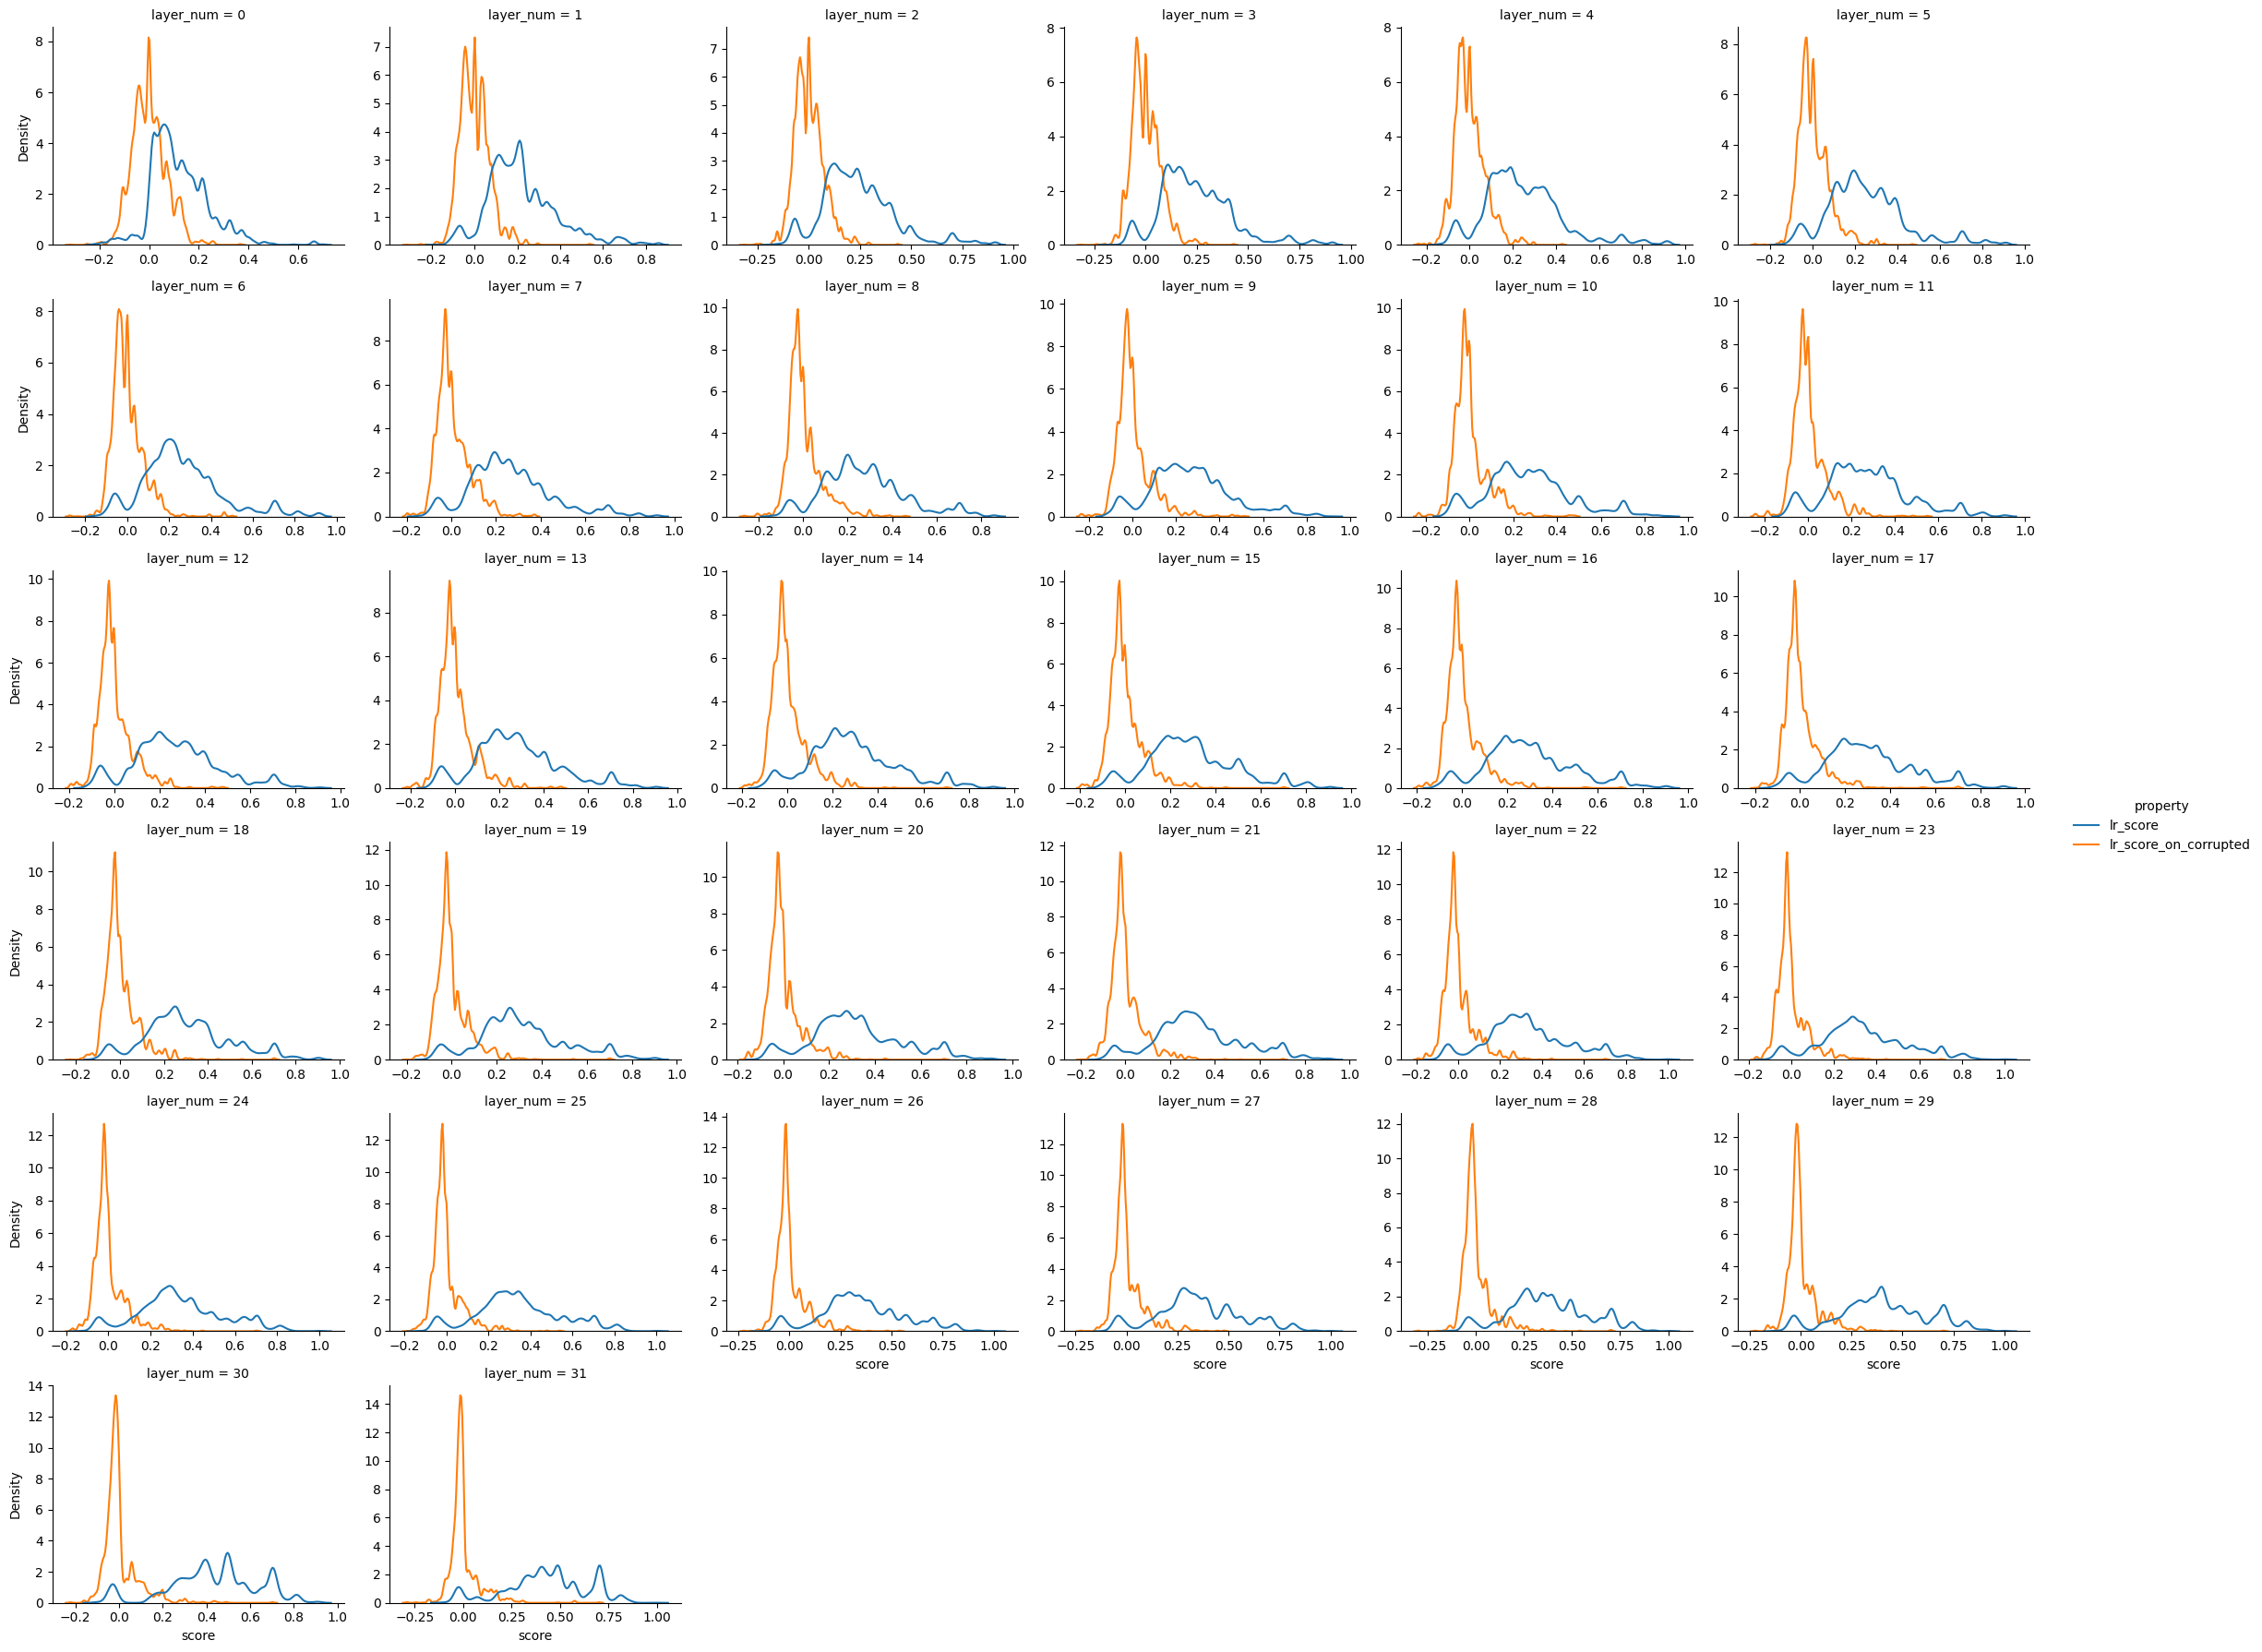

In [21]:
# Just to get a sense of the distributions
score_results = results.unpivot(index=['Entry Name', 'layer_num', ], on=['lr_score', 'lr_score_on_corrupted'], value_name = 'score', variable_name='property')
sns.displot(score_results,
    x = 'score',
    hue='property',
    col = 'layer_num',
    col_wrap = 6,
    kind = 'kde', 
    common_norm=False,
    height = 3,
    aspect = 1.25,
    facet_kws={'sharey': False, 'sharex': False},
)

Just by eye, the scores for Logistic Regression on correct labels are different than those on scrambled/corrupted labels. Statistical testing to increase confidence:

In [23]:
significance_threshold = 0.005

layer_nums = sorted(results['layer_num'].unique().to_list())

layerwise_stats = []

for layer_num in layer_nums:
    # Filter by layer number and group by protein id
    layer_results = results.filter(pl.col('layer_num') == layer_num).group_by('id').mean()

    # Specify control and treatment
    treatment_scores = layer_results['lr_score']
    control_scores = layer_results['lr_score_on_corrupted']

    # Test whether there are statistical differences in score, score on corrupted
    stat, p_val = stats.wilcoxon(treatment_scores, control_scores, alternative='greater')
        
    layerwise_stats.append({
        'layer': layer_num,
        'stat': stat,
        'p_value': p_val,
        'is_significant': p_val < significance_threshold,
        'mean_diff': (treatment_scores - control_scores).mean()
    })

# Convert to DataFrame for easy viewing
stats_df = pl.DataFrame(layerwise_stats)

    # # If there are significant differences
    # if stat_test.pvalue < significance_threshold:
    #     # Do a posthoc test

In [30]:
stats_df.sort('p_value')

layer,stat,p_value,is_significant,mean_diff
i64,f64,f64,i64,f64
31,115603.0,7.7932e-79,1,0.442537
30,115876.0,1.9174e-78,1,0.443488
29,114958.0,4.0242e-77,1,0.41332
27,115270.0,7.6487e-77,1,0.368269
26,114849.0,7.8030e-77,1,0.363127
…,…,…,…,…
11,113117.0,2.7205e-71,1,0.275702
10,113033.0,4.4351e-71,1,0.273568
2,112987.0,5.7943e-71,1,0.251578


It looks like there is a significant difference at all layers, using this significance test.